In [1]:
%matplotlib qt

In [2]:
import pdb
# import biosignalsnotebooks as bsnb
import CalculateSMR
import matlab
import matplotlib.pyplot as plt
import numpy as np
import mne
from analyzer import Analyzer
from data_loader import DataLoader
from preprocessing import Preprocessing


setup variables

In [3]:
pre_process = True
mode = "MRCP"
generate_report = False
Ref = "origin"
exp_counter = 148
if mode == "MRCP":
    low_freq = 0.05
    hi_freq = 5
elif mode == "SMR":
    low_freq = 7
    hi_freq = 30

import data

In [4]:
data_loader = DataLoader(exp_counter=exp_counter)
data_loader.init_task_dependent_variables()
data_loader.load_data()
data_loader.create_raw_object()
data_loader.create_event()
data_loader.add_EMG_event()
# BV_header_file = r"D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\BP_record\sample_data\NE.vhdr"
# philistine.mne.write_raw_brainvision(data_loader.raw_array, BV_header_file, data_loader.event_array)
print(
    "-----------------------------------------------------------------------------------------------------------"
    "\n{}\n------------------------------------------------------------------------------------------------------"
        .format(data_loader.exp_name))

Creating RawArray with float64 data, n_channels=31, n_times=1791011
    Range : 0 ... 1791010 =      0.000 ...  3582.020 secs
Ready.
-----------------------------------------------------------------------------------------------------------
Rebecca WEIE LR
------------------------------------------------------------------------------------------------------


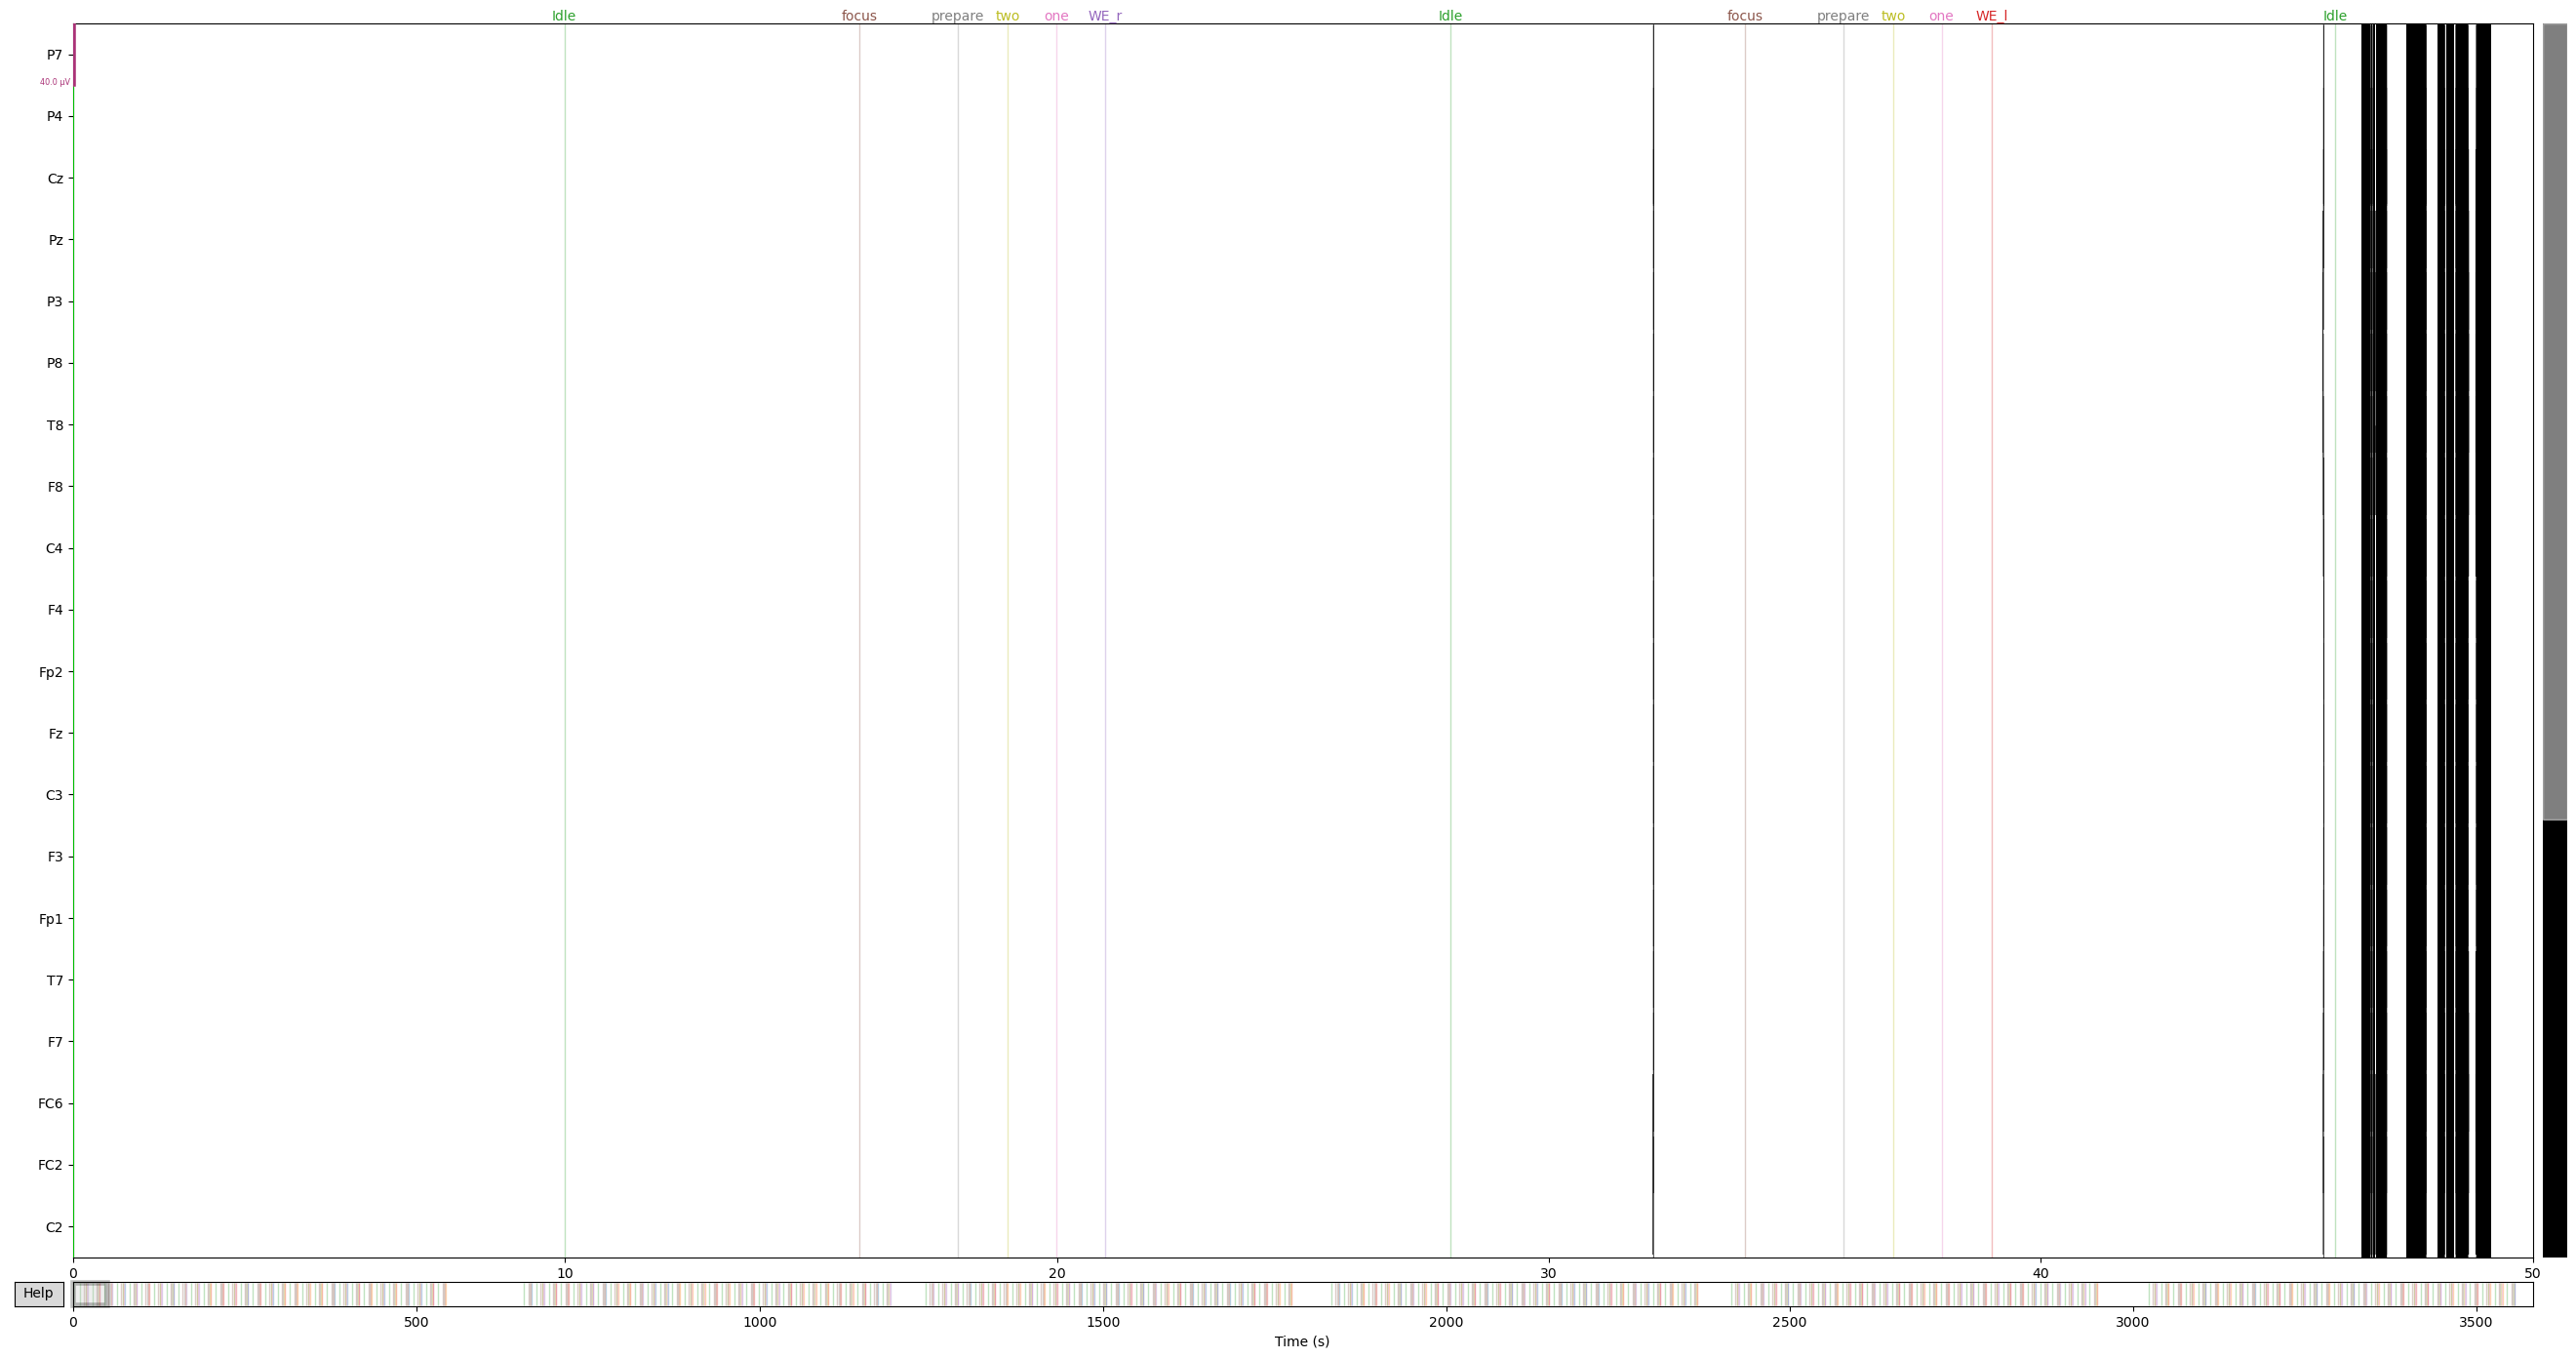

In [5]:
data_loader.raw_array.plot(duration=50)

preprocessing

In [5]:
preprocessing = Preprocessing(data_loader)

In [6]:
preprocessing.apply_filter(hi=hi_freq, low=low_freq, order=2, duration=200)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.05 - 5 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoffs at 0.05, 5.00 Hz: -6.02, -6.02 dB

select bad span of signal..., press c to continue


In [7]:
preprocessing.apply_ICA()

Fitting ICA to data using 27 channels (please be patient, this may take a while)
Inferring max_pca_components from picks
Omitting 62873 of 1791011 (3.51%) samples, retaining 1728138 (96.49%) samples.
Selecting by number: 27 components
Fitting ICA took 57.0s.


In [8]:
preprocessing.plot_exclude_ICA()

Transforming to ICA space (27 components)
Zeroing out 4 ICA components
Transforming to ICA space (27 components)
Zeroing out 4 ICA components


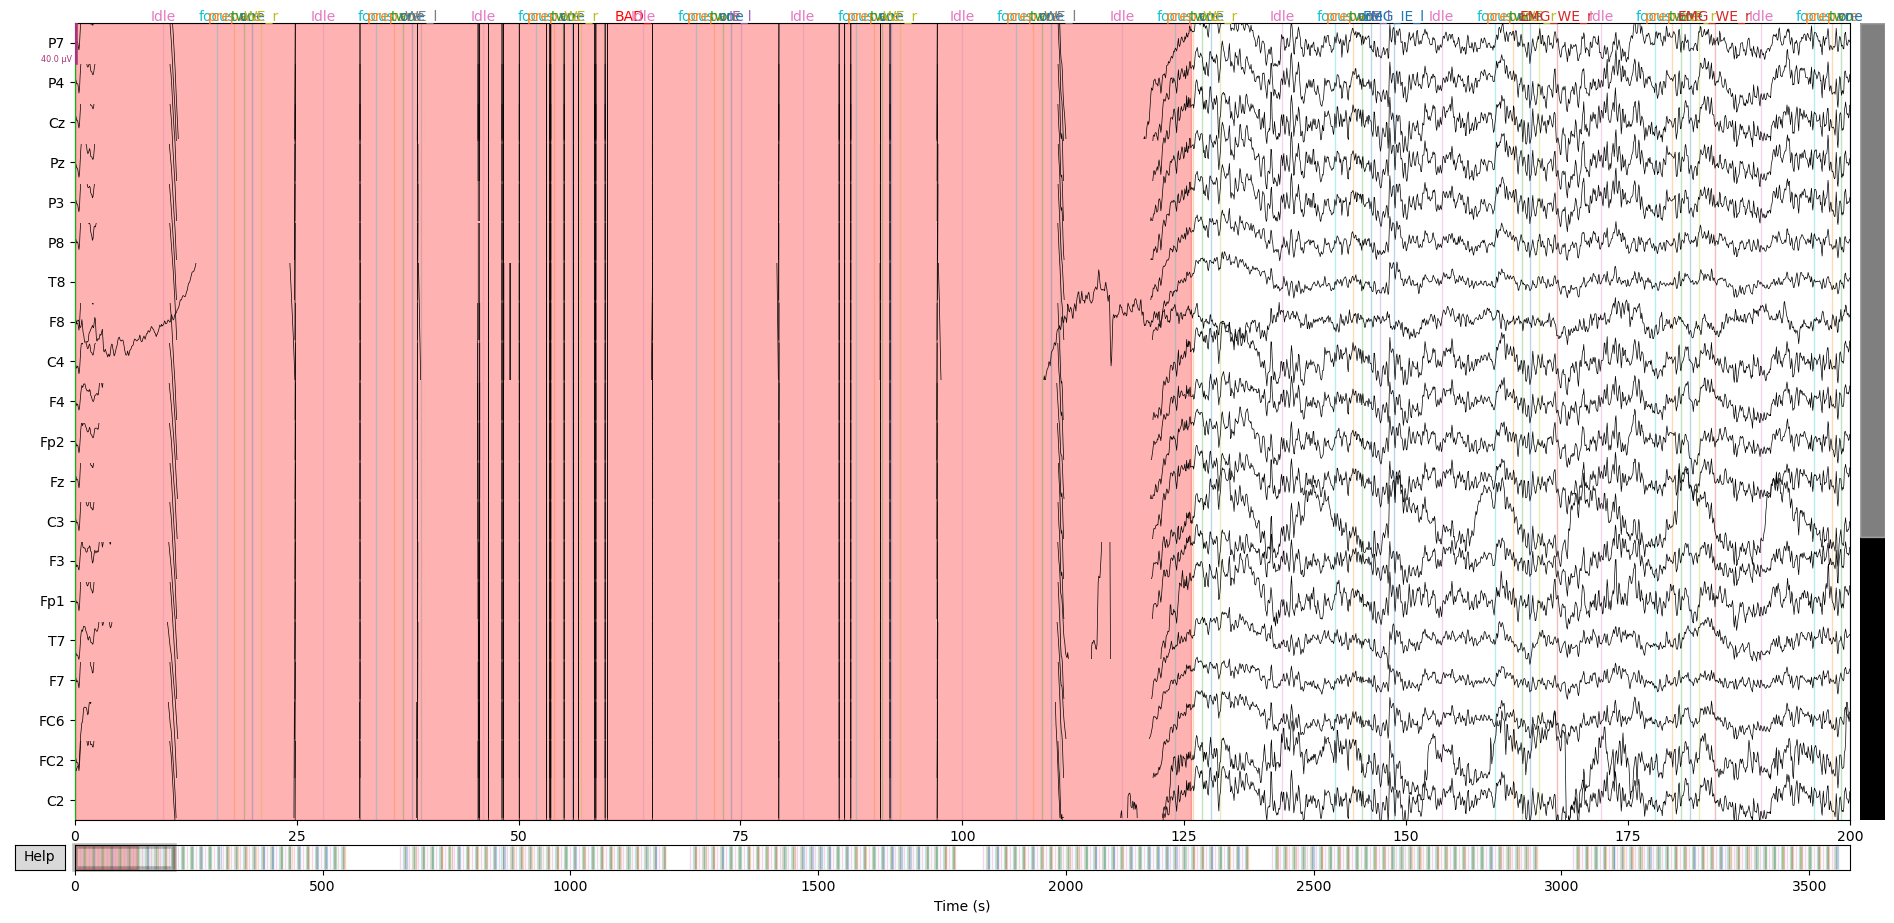

In [9]:
preprocessing.filtered_raw_array.plot(duration=200)

In [10]:
preprocessing.interpolate_bad_chs(duration=200)

Interpolating bad channels
    Automatic origin fit: head of radius 89.3 mm
Computing interpolation matrix from 24 sensor positions
Interpolating 3 sensors


In [11]:
preprocessing.save_consecutive_data(special_name='referenced_using_{}'.format(Ref))

Overwriting existing file.
Writing D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\processed_data\consecutive_data\Rebecca WEIE LR_processed_BPF_0.05Hz_5Hz_referenced_using_origin.fif


D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\offline_processing\preprocessing.py:111: RuntimeWarning: This filename (D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\processed_data\consecutive_data\Rebecca WEIE LR_processed_BPF_0.05Hz_5Hz_referenced_using_origin.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz or _meg.fif
  self.hi, special_name), overwrite=True)


Closing D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\processed_data\consecutive_data\Rebecca WEIE LR_processed_BPF_0.05Hz_5Hz_referenced_using_origin.fif [done]
